# 🌾 India Crop Yield Prediction — Notebook 4: Advanced Ensemble Models

**Goal:** Train and compare ensemble methods — **Random Forest, Gradient Boosting, XGBoost, LightGBM, CatBoost** — and select the best performer.

---

## 1. Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import warnings

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Optional — install with: pip install xgboost lightgbm catboost
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print('XGBoost not installed. Run: pip install xgboost')

try:
    from lightgbm import LGBMRegressor
    HAS_LGB = True
except ImportError:
    HAS_LGB = False
    print('LightGBM not installed. Run: pip install lightgbm')

try:
    from catboost import CatBoostRegressor
    HAS_CAT = True
except ImportError:
    HAS_CAT = False
    print('CatBoost not installed. Run: pip install catboost')

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
print('\nLibraries loaded.')


Libraries loaded.


## 2. Load Processed Data

In [3]:
# Use raw (unscaled) data — tree-based models don't need scaling
X_train = pd.read_csv('processed/X_train_raw.csv')
X_val   = pd.read_csv('processed/X_val_raw.csv')
X_test  = pd.read_csv('processed/X_test_raw.csv')
y_train = pd.read_csv('processed/y_train.csv').squeeze()
y_val   = pd.read_csv('processed/y_val.csv').squeeze()
y_test  = pd.read_csv('processed/y_test.csv').squeeze()

with open('processed/feature_cols.json') as f:
    feature_cols = json.load(f)

print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')

Train: (12149, 16), Val: (2604, 16), Test: (2604, 16)


## 3. Metrics Helper

In [4]:
def get_metrics(name, model, X_tr, y_tr, X_v, y_v):
    preds_tr = model.predict(X_tr)
    preds_v  = model.predict(X_v)
    rows = []
    for split, y_true, y_pred in [('Train', y_tr, preds_tr), ('Val', y_v, preds_v)]:
        rows.append({
            'Model': name, 'Split': split,
            'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
            'MAE':  mean_absolute_error(y_true, y_pred),
            'R2':   r2_score(y_true, y_pred)
        })
    return rows

print('Helper defined.')

Helper defined.


## 4. Random Forest

In [5]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)
print('Training Random Forest...')
rf.fit(X_train, y_train)

all_results = []
all_results.extend(get_metrics('Random Forest', rf, X_train, y_train, X_val, y_val))
print('Random Forest — Val R²:', r2_score(y_val, rf.predict(X_val)))

Training Random Forest...
Random Forest — Val R²: 0.9458471476099032


## 5. Extra Trees

In [6]:
et = ExtraTreesRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)
print('Training Extra Trees...')
et.fit(X_train, y_train)
all_results.extend(get_metrics('Extra Trees', et, X_train, y_train, X_val, y_val))
print('Extra Trees — Val R²:', r2_score(y_val, et.predict(X_val)))

Training Extra Trees...
Extra Trees — Val R²: 0.9324369251487619


## 6. Gradient Boosting (sklearn)

In [7]:
gb = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    random_state=42
)
print('Training Gradient Boosting (sklearn)...')
gb.fit(X_train, y_train)
all_results.extend(get_metrics('Gradient Boosting', gb, X_train, y_train, X_val, y_val))
print('Gradient Boosting — Val R²:', r2_score(y_val, gb.predict(X_val)))

Training Gradient Boosting (sklearn)...
Gradient Boosting — Val R²: 0.9476983770079279


## 7. XGBoost

In [8]:
if HAS_XGB:
    xgb = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )
    print('Training XGBoost...')
    xgb.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    all_results.extend(get_metrics('XGBoost', xgb, X_train, y_train, X_val, y_val))
    print('XGBoost — Val R²:', r2_score(y_val, xgb.predict(X_val)))
else:
    xgb = None
    print('XGBoost skipped — not installed.')

Training XGBoost...
XGBoost — Val R²: 0.9558570602871264


## 8. LightGBM 

In [9]:
if HAS_LGB:
    lgb = LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=63,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    print('Training LightGBM...')
    lgb.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)]
    )
    all_results.extend(get_metrics('LightGBM', lgb, X_train, y_train, X_val, y_val))
    print('LightGBM — Val R²:', r2_score(y_val, lgb.predict(X_val)))
else:
    lgb = None
    print('LightGBM skipped — not installed.')

Training LightGBM...
LightGBM — Val R²: 0.9529658041409846


## 9. CatBoost 

In [10]:
if HAS_CAT:
    cat = CatBoostRegressor(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        l2_leaf_reg=3,
        random_state=42,
        verbose=0
    )
    print('Training CatBoost...')
    cat.fit(X_train, y_train, eval_set=(X_val, y_val), use_best_model=True)
    all_results.extend(get_metrics('CatBoost', cat, X_train, y_train, X_val, y_val))
    print('CatBoost — Val R²:', r2_score(y_val, cat.predict(X_val)))
else:
    cat = None
    print('CatBoost skipped — not installed.')

Training CatBoost...
CatBoost — Val R²: 0.9423665926933323


## 10. Results Summary

In [11]:
results_df = pd.DataFrame(all_results)
val_df = results_df[results_df['Split'] == 'Val'].sort_values('R2', ascending=False)

print('=== Validation Results (sorted by R²) ===')
print(val_df[['Model', 'R2', 'RMSE', 'MAE']].to_string(index=False))

=== Validation Results (sorted by R²) ===
            Model       R2     RMSE      MAE
          XGBoost 0.955857 0.291715 0.150613
         LightGBM 0.952966 0.301117 0.151553
Gradient Boosting 0.947698 0.317531 0.165664
    Random Forest 0.945847 0.323102 0.150564
         CatBoost 0.942367 0.333323 0.182423
      Extra Trees 0.932437 0.360897 0.173226


## 11. Visual Comparison

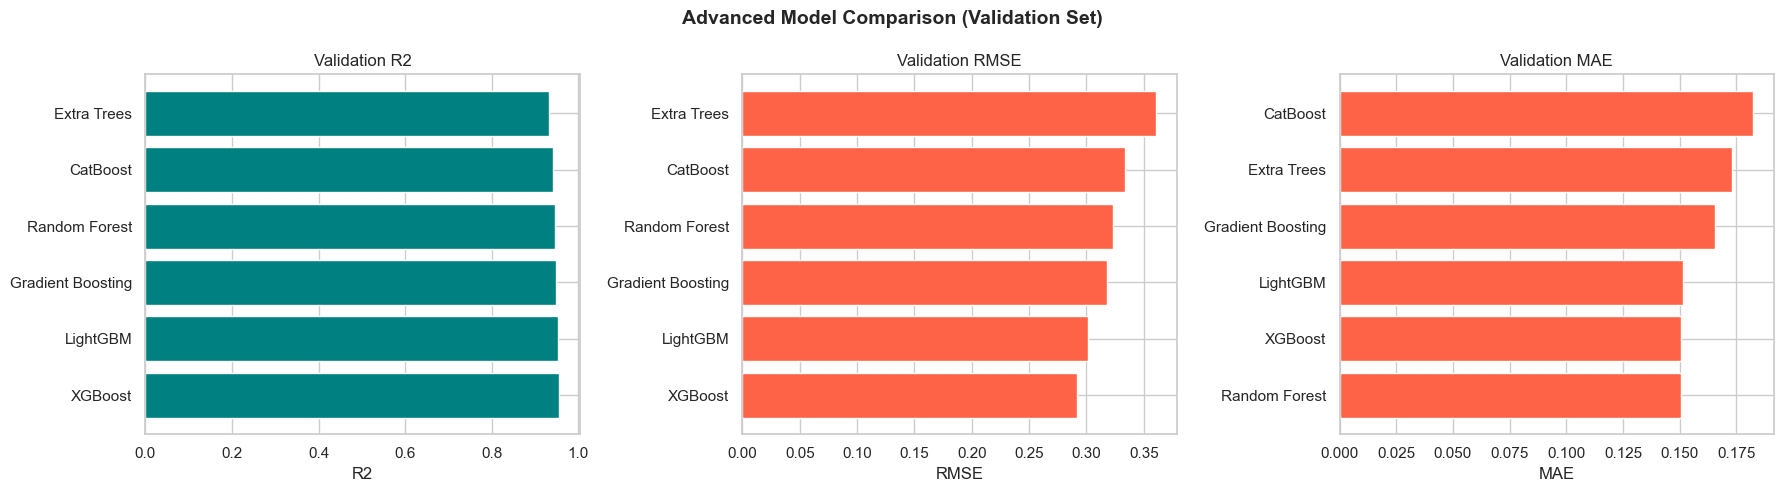

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric in zip(axes, ['R2', 'RMSE', 'MAE']):
    ascending = metric != 'R2'
    data = val_df.sort_values(metric, ascending=ascending)
    color = 'teal' if metric == 'R2' else 'tomato'
    ax.barh(data['Model'], data[metric], color=color, edgecolor='white')
    ax.set_title(f'Validation {metric}', fontsize=12)
    ax.set_xlabel(metric)

plt.suptitle('Advanced Model Comparison (Validation Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('advanced_model_comparison.png')
plt.show()

## 12. Feature Importance — Best Model

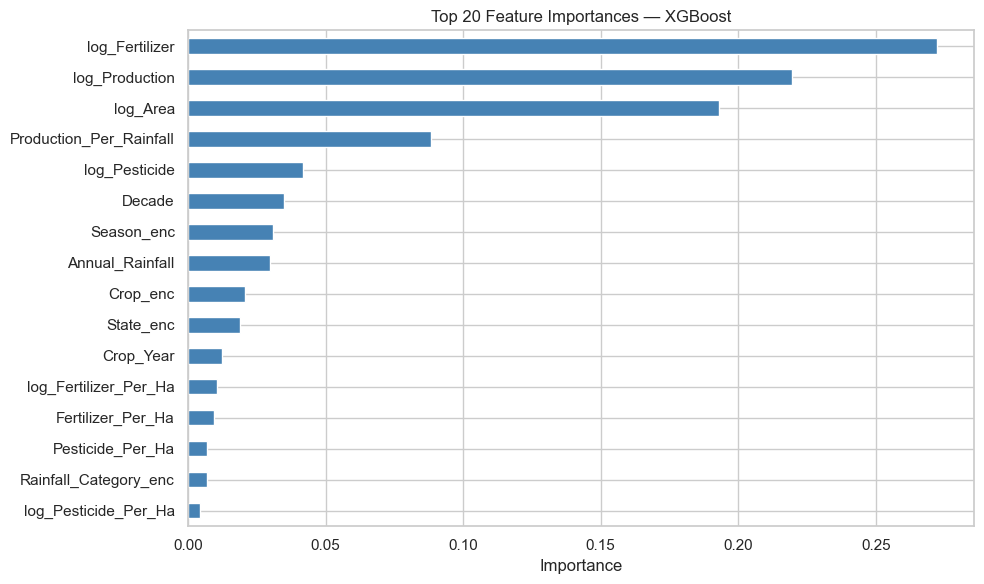

In [13]:
best_name = val_df.iloc[0]['Model']
model_map = {
    'Random Forest': rf,
    'Extra Trees': et,
    'Gradient Boosting': gb,
    'XGBoost': xgb,
    'LightGBM': lgb,
    'CatBoost': cat
}
best_model = model_map[best_name]

if hasattr(best_model, 'feature_importances_'):
    imp = pd.Series(best_model.feature_importances_, index=X_train.columns)
    imp = imp.sort_values(ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(10, 6))
    imp.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.invert_yaxis()
    ax.set_title(f'Top 20 Feature Importances — {best_name}')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.savefig('feature_importance_best.png')
    plt.show()
else:
    print(f'{best_name} does not expose feature_importances_ directly.')

## 13. Save Best Model & Results

In [14]:
import os
os.makedirs('models', exist_ok=True)

joblib.dump(best_model, 'models/best_advanced_model.pkl')
results_df.to_csv('models/advanced_results.csv', index=False)

print(f'Best model: {best_name}')
print(f'Saved to models/best_advanced_model.pkl')
print(f'Val R² = {val_df.iloc[0]["R2"]:.4f}')
print(f'Val RMSE = {val_df.iloc[0]["RMSE"]:.4f}')

Best model: XGBoost
Saved to models/best_advanced_model.pkl
Val R² = 0.9559
Val RMSE = 0.2917


---
✅ **Advanced models complete.** Proceed to `05_hyperparameter_tuning.ipynb`.